                                            **ASSIGNMENT NO. :- 8**
---
**TITLE** :- Implement AI security measures to protect against adversarial attacks and data breaches.

---
**NAME** :- BHOSALE SUSHTI AMAR

**ROLL NO.** :-23107008

**CLASS** :- TY(A)

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

In [31]:
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [32]:
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

In [33]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [34]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(x_train, y_train, epochs=3, validation_split=0.1)

Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9046 - loss: 0.3034 - val_accuracy: 0.9857 - val_loss: 0.0464
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9852 - loss: 0.0470 - val_accuracy: 0.9897 - val_loss: 0.0385
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9907 - loss: 0.0290 - val_accuracy: 0.9885 - val_loss: 0.0417


In [35]:
loss, acc = model.evaluate(x_test, y_test)
print("Clean Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9846 - loss: 0.0477
Clean Accuracy: 0.9883000254631042


**FGSM Attack Function**

In [36]:
loss_object = tf.keras.losses.SparseCategoricalCrossentropy()
def create_adversarial_pattern(image, label):
    image = tf.cast(image, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(image)
        prediction = model(image)
        loss = loss_object(label, prediction)
    gradient = tape.gradient(loss, image)
    signed_grad = tf.sign(gradient)
    return signed_grad

**Create Adversarial Image**

In [37]:
epsilon = 0.1

img = x_test[0:1]
label = y_test[0:1]

perturbations = create_adversarial_pattern(img, label)

adv_image = img + epsilon * perturbations
adv_image = tf.clip_by_value(adv_image, 0, 1)

In [38]:
print("Original Prediction:", np.argmax(model.predict(img)))
print("Adversarial Prediction:", np.argmax(model.predict(adv_image)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Original Prediction: 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Adversarial Prediction: 7


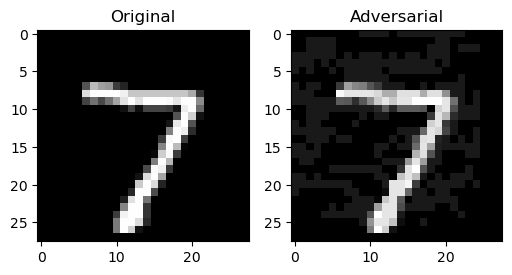

In [39]:
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img[0].squeeze(), cmap='gray')

plt.subplot(1,2,2)
plt.title("Adversarial")
plt.imshow(adv_image[0].numpy().squeeze(), cmap='gray')

plt.show()

**Data Security (Hashing)**

In [40]:
import hashlib
def encrypt_data(data):
    return hashlib.sha256(data.tobytes()).hexdigest()
print("Dataset Hash:", encrypt_data(x_train))

Dataset Hash: a32bf55afb4a5c9cd4224cab3fb024d518fc9e9254ca071befcf5a828eff8c73
